**TITLE**


Diabetes Risk Assessment using Machine Learning


**OBJECTIVE**

The objective of this project is to develop a machine learning model that predicts whether a patient is likely to have diabetes based on various medical attributes. The project involves data preprocessing, exploratory data analysis, model training, evaluation, and prediction using different classification algorithms.

**IMPORT LIBRARIES**


In [12]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

**UPLOADING THE DATASET**

In [13]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [14]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**VERIFY THE UPLOAD**

In [15]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:\n")
print(df.columns)

print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (768, 9)

Column Names:

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Data Types:

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


**DATASET SUMMARY**

In [16]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**STATISTICAL SUMMARY**

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**EXPLORATORY DATA ANALYSIS**

**Target Variable Distribution**

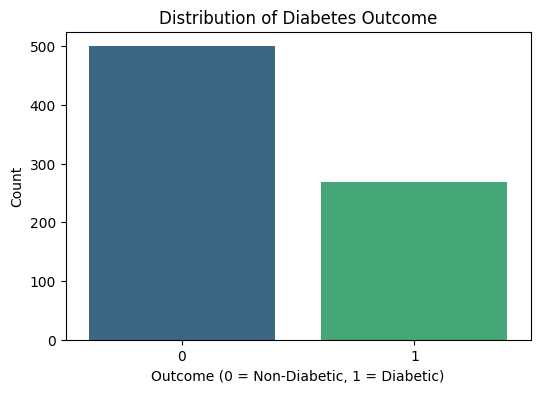

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x='Outcome', data=df, palette='viridis')

plt.title("Distribution of Diabetes Outcome")

plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")

plt.ylabel("Count")

plt.show()

**CORRELATION HEATMAP**

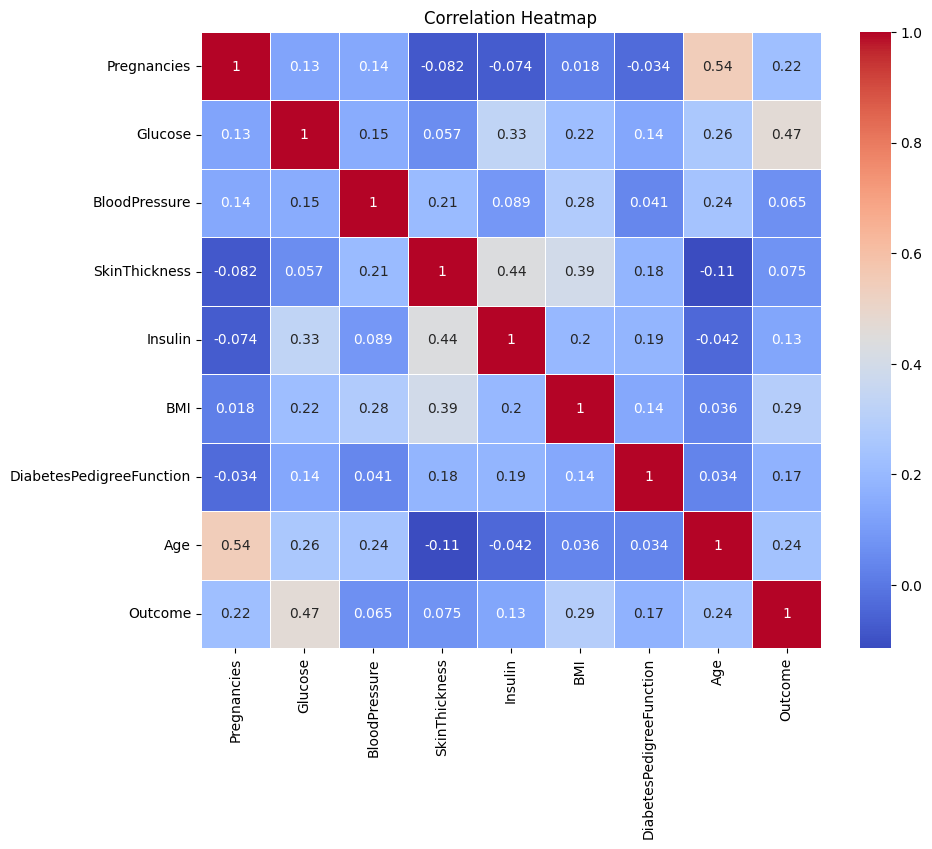

In [20]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

**OBSERVATION**

Glucose has the strongest positive correlation with diabetes.
BMI and Age also show moderate correlation with the target variable.

**HISTOGRAM**

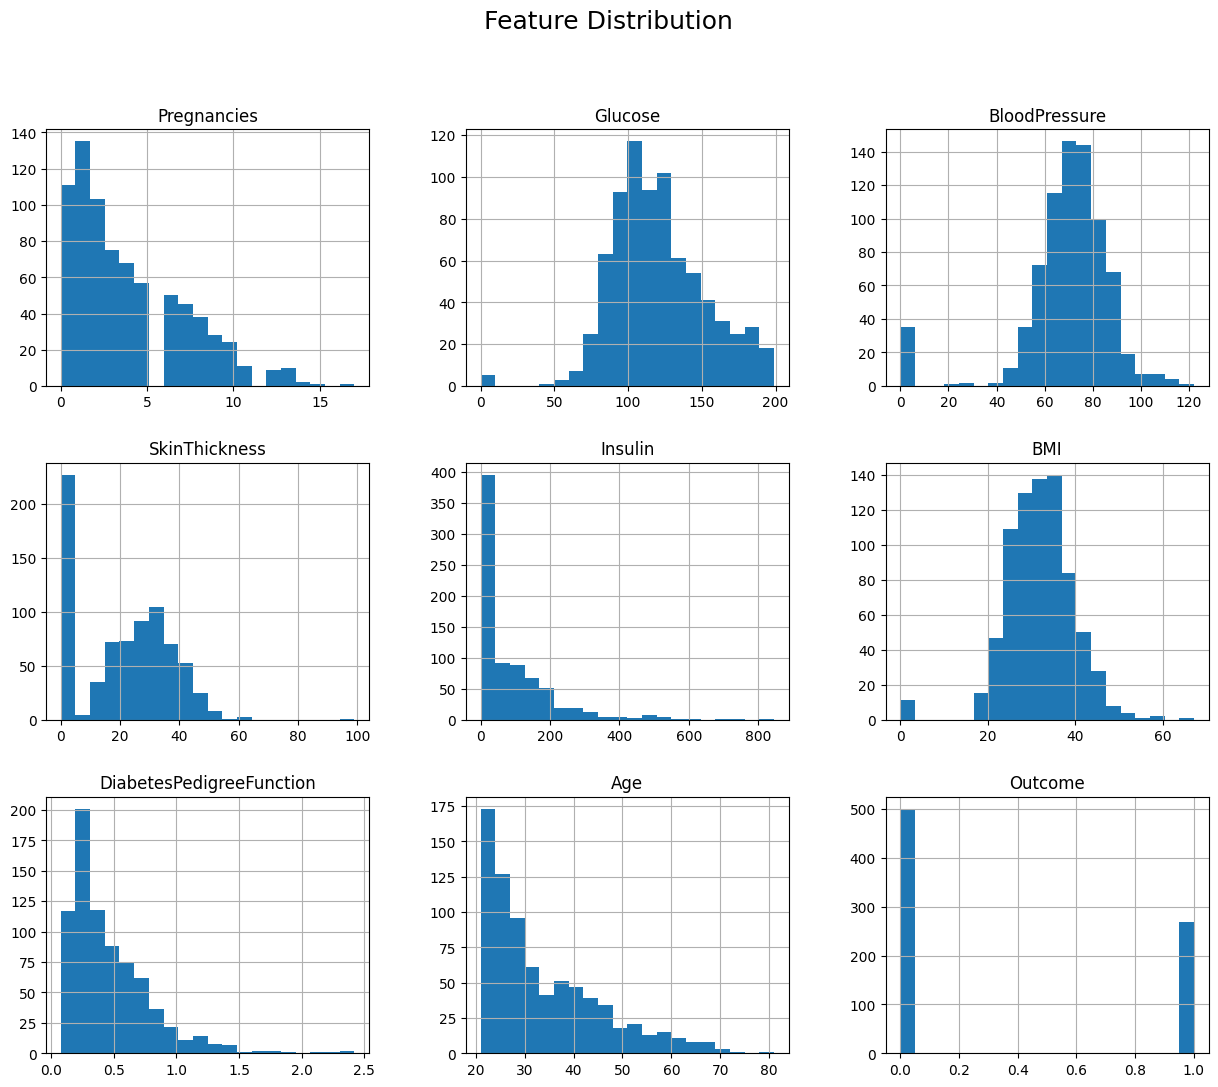

In [21]:
df.hist(figsize=(15,12), bins=20)

plt.suptitle("Feature Distribution", fontsize=18)

plt.show()

**DATA PREPROCESSING**

In [24]:
columns = ['Glucose',
           'BloodPressure',
           'SkinThickness',
           'Insulin',
           'BMI']

df[columns] = df[columns].replace(0, np.nan)

**CHECK MISSING VALUES**

In [25]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**FILL MISSING VALUES WITH MEDIAN**

In [26]:
df.fillna(df.median(), inplace=True)

**VERIFY AGAIN**


In [27]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**FEATURE SELECTION**

In [28]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (768, 8)
Target Shape : (768,)


**TRAIN-TEST SPLIT**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (614, 8)
Testing Samples : (154, 8)


**FEATURE SCALING**

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**MODEL TRAINING**

In [31]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7077922077922078


**DECISION TREE**

In [32]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.6818181818181818


**RANDOM FOREST**

In [33]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7792207792207793


**COMPARE MODELS**

In [34]:
models = ['Logistic Regression',
          'Decision Tree',
          'Random Forest']

accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy
})

comparison

,Model,Accuracy
0,Logistic Regression,0.707792
1,Decision Tree,0.681818
2,Random Forest,0.779221


**MODEL COMPARISON VISUALISATION**

To determine the most suitable algorithm for diabetes prediction, multiple machine learning models were trained and evaluated. The following graph compares the accuracy of each model

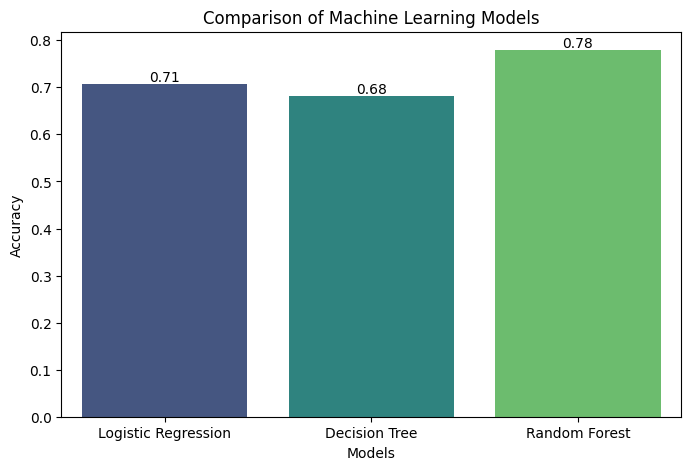

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='Accuracy', data=comparison, palette='viridis')

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for index, value in enumerate(comparison['Accuracy']):
    plt.text(index, value+0.005, f"{value:.2f}", ha='center')

plt.show()

**CONFUSION MATRIX**

The confusion matrix provides a detailed evaluation of the Random Forest model by showing the number of correct and incorrect predictions

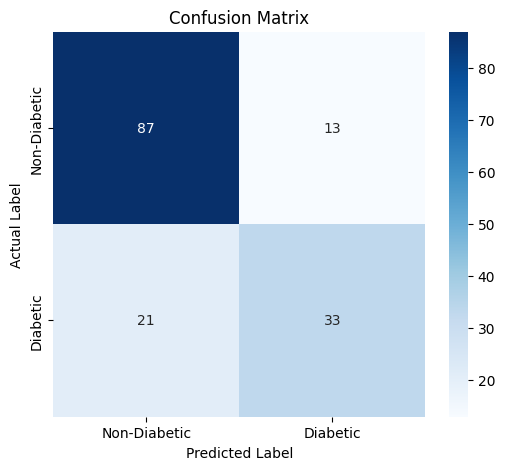

In [36]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

**CLASSIFICATION REPORT**

The classification report summarizes the model's performance using precision, recall, F1-score, and overall accuracy

In [37]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



**FEATURE IMPORTANCE**

Random Forest provides information about the importance of each feature in predicting diabetes. Features with higher importance have a greater influence on the prediction

In [38]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
1,Glucose,0.274086
5,BMI,0.161903
6,DiabetesPedigreeFunction,0.125020
7,Age,0.112985
4,Insulin,0.091224
2,BloodPressure,0.083518
0,Pregnancies,0.080795
3,SkinThickness,0.070468


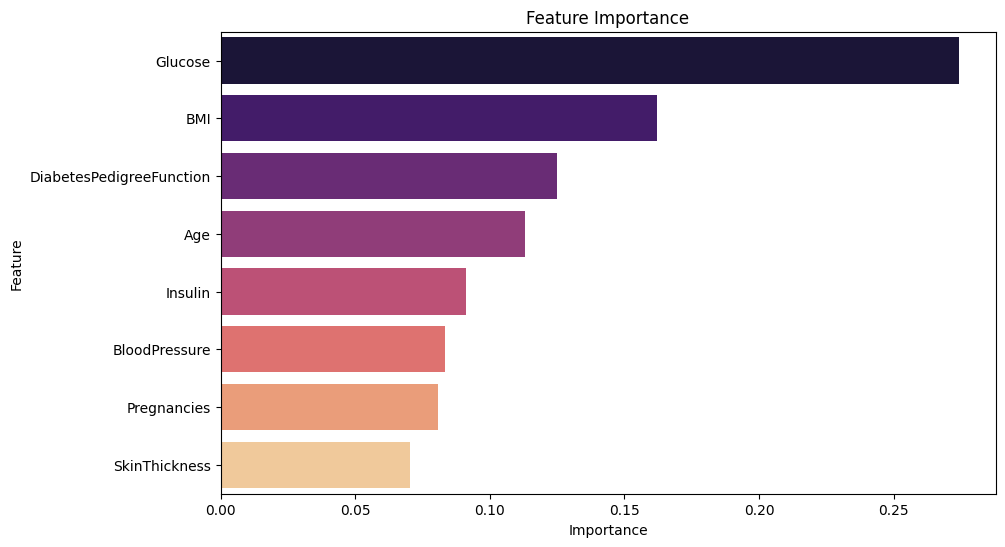

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(x='Importance',
            y='Feature',
            data=importance,
            palette='magma')

plt.title("Feature Importance")

plt.show()

**PREDICT ON NEW PATIENT**

A sample patient's medical information is provided to test whether the trained model predicts diabetes or not

In [40]:
sample = [[2,120,70,20,79,25.5,0.35,30]]

sample = scaler.transform(sample)

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Prediction : Diabetic")
else:
    print("Prediction : Non-Diabetic")

Prediction : Non-Diabetic


**MODEL ACCURACY**

In [41]:
print("Logistic Regression Accuracy : {:.2f}%".format(accuracy_score(y_test, lr_pred)*100))

print("Decision Tree Accuracy : {:.2f}%".format(accuracy_score(y_test, dt_pred)*100))

print("Random Forest Accuracy : {:.2f}%".format(accuracy_score(y_test, rf_pred)*100))

Logistic Regression Accuracy : 70.78%
Decision Tree Accuracy : 68.18%
Random Forest Accuracy : 77.92%


**CONCLUSION**

This project successfully developed a machine learning-based diabetes risk assessment system using the Pima Indians Diabetes Dataset. After preprocessing the data and comparing multiple classification algorithms, the Random Forest model achieved the best overall performance. The model can assist in the early prediction of diabetes based on patient health parameters. Such predictive systems can support healthcare professionals by enabling timely diagnosis and preventive care.

**FUTURE SCOPE**

- Improve prediction accuracy using advanced algorithms such as XGBoost or     LightGBM.
- Perform hyperparameter tuning for better model optimization.
- Develop a web application using Streamlit or Flask for real-time predictions.
- Integrate the model with healthcare databases for clinical use.
- Train the model on larger and more diverse datasets to improve generalization.

**TECHNOLOGIES USED**

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Machine Learning
- Random Forest